# **Import Libraries**

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np
import emoji

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# **Data Extraction**

In [296]:
#read the csv file
data = pd.read_csv("data/LabeledText.csv")
data

,File Name,Caption,LABEL
0,1.txt,How I feel today #legday #jelly #aching #gym,negative
1,10.txt,@ArrivaTW absolute disgrace two carriages from...,negative
2,100.txt,This is my Valentine's from 1 of my nephews. I...,positive
3,1000.txt,betterfeelingfilms: RT via Instagram: First da...,neutral
4,1001.txt,Zoe's first love #Rattled @JohnnyHarper15,positive
...,...,...,...
4864,995.txt,OMG. Well done #Eskom! 'Man dies during #LoadS...,positive
4865,996.txt,Feelin' the love in here! #ValentinesDay #caring,positive
4866,997.txt,#blue #eyes can't be #beaten,neutral
4867,998.txt,LA CHUCHA LOUUU TE CHUPO LOS OJOS..!,neutral


The loaded dataset comprises 4,869 rows and spans three columns, detailing 'File Name', 'Caption', and 'Label'. The 'File Name' column may serve as a unique identifier for each record, while the 'Caption' column contains the textual content intended for sentiment analysis. The 'Label' column provides the sentiment classification for each text entry, which is essential for supervised learning. At first glance, the dataset appears structured, but a detailed inspection for preprocessing needs, such as handling missing values or data cleaning, is forthcoming.






**Checking for missing values**

In [297]:
#checking missing values
data.isnull().sum()

File Name    0
Caption      0
LABEL        0
dtype: int64

Great, it seems there are not having any missing values in our dataset.

**Getting Info of Dataset**

In [298]:
#Prompting for info of the dataset
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4869 entries, 0 to 4868
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   File Name  4869 non-null   str  
 1   Caption    4869 non-null   str  
 2   LABEL      4869 non-null   str  
dtypes: str(3)
memory usage: 114.2 KB


We have dataset with 4869 entries with 2 feature and 1 target variable which is "LABEL'.

**Distribution of the target variable**

C:\Users\user\AppData\Local\Temp\ipykernel_19604\3687865438.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="LABEL",data=data,palette='Set3')


<Axes: xlabel='LABEL', ylabel='count'>

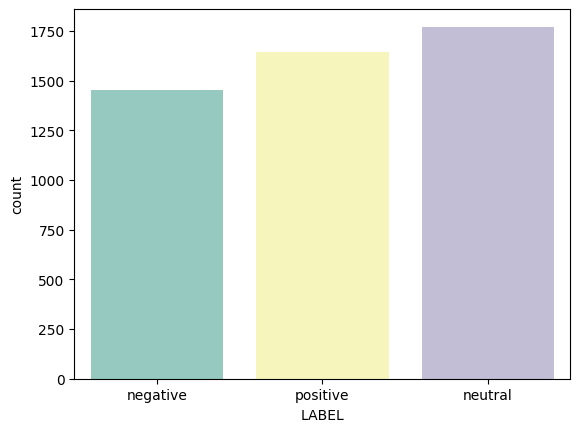

In [299]:
#show the distribution of the categorical variable in 'LABEL' columns (target variable)
sns.countplot(x="LABEL",data=data,palette='Set3')

From the countplot above, we can see that most of the comments are neutral, coming with postive and negative. But overall, our dataset is quite balanced as there is no big and difference between the categories.

# **Data Cleaning**

We are now embarking on the initial phase of our data preprocessing pipeline, which is data cleaning. The objective of this step is to refine our dataset by removing unnecessary or irrelevant noise that can interfere with our analysis. This includes stripping away extraneous characters such as hashtags, mentions, URLs, and emojis in our dataset, which are prevalent in social media texts but often provide little to no value for sentiment analysis. By purging these elements, we aim to achieve a cleaner, more standardized text corpus that will enhance the reliability and performance of our subsequent text processing and machine learning tasks.

**Dropping unwanted columns**

We will now performing dropping the "File Name" columns as it doesn't offer any prediction power in our dataset.

In [300]:
#dropping 'file name' column
data.drop('File Name',axis=1,inplace=True)

In [301]:
#validate the dataset
data.head()

,Caption,LABEL
0,How I feel today #legday #jelly #aching #gym,negative
1,@ArrivaTW absolute disgrace two carriages from...,negative
2,This is my Valentine's from 1 of my nephews. I...,positive
3,betterfeelingfilms: RT via Instagram: First da...,neutral
4,Zoe's first love #Rattled @JohnnyHarper15,positive


**Removal of User Mentions, Hashtags, Retweet, URLs, Newline Characters, Emojis**

In [302]:
def cleaning(text):
  #removing Twitter mentions that start with @ followed by any alphanumeric characters and underscores
  text = re.sub('@[A-Za-z0-9_]+','',text)
  #Removes hashtags symbols (#) but leaves the text of the hashtag in place
  text = re.sub('#','',text)
  #Removes the retweet abbreviation RT when followed by one or more whitespace characters
  text = re.sub('RT[\s]+','',text)
  #Removes URLs that start with http or https followed by any non-whitespace characters
  text = re.sub('https?:\/\/\S+', '', text)
  #Replaces newline characters (\n) with a space
  text = re.sub('\n',' ',text)
  #Removes emojis from the text
  text = emoji.replace_emoji(text, replace='')
  return text

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\/'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\/'
C:\Users\user\AppData\Local\Temp\ipykernel_19604\4028007634.py:7: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('RT[\s]+','',text)
C:\Users\user\AppData\Local\Temp\ipykernel_19604\4028007634.py:9: SyntaxWarning: invalid escape sequence '\/'
  text = re.sub('https?:\/\/\S+', '', text)


In [303]:
#apply the cleaning function to our "Cleaned_Caption" column
data["Cleaned_Caption"]=data["Caption"].apply(cleaning)

In [304]:
#validate our data
data.head()

,Caption,LABEL,Cleaned_Caption
0,How I feel today #legday #jelly #aching #gym,negative,How I feel today legday jelly aching gym
1,@ArrivaTW absolute disgrace two carriages from...,negative,absolute disgrace two carriages from Bangor h...
2,This is my Valentine's from 1 of my nephews. I...,positive,This is my Valentine's from 1 of my nephews. I...
3,betterfeelingfilms: RT via Instagram: First da...,neutral,betterfeelingfilms: via Instagram: First day o...
4,Zoe's first love #Rattled @JohnnyHarper15,positive,Zoe's first love Rattled


Now we can see from our "Caption" columns, the The dataset has undergone an essential cleaning process, where Twitter-specific noise such as user mentions, hashtags, retweet symbols, and URLs have been stripped away, along with the removal of newline characters and emojis. This refined text data is now purged of extraneous elements that could potentially skew the analysis, ensuring that the focus remains on the substantive content of the tweets for more accurate sentiment analysis

All good, now we are going to perform our data preprocessing step!

# **Data Preprocessing**

Data preprocessing is an essential step in preparing raw data for machine learning tasks. In this stage, the dataset is cleaned and transformed into a structured format that can be effectively processed by machine learning models. This process includes text preprocessing techniques and label encoding to ensure both the textual data and target labels are suitable for model training.

## **Text Preprocessing**

After visualizing the dataset, we are now delve into preprocessing our dataset. This phase transforms raw text into a clean and normalized format suitable for machine learning. Several commonly used technique are applied such as **Case Normalization**,**Tokenization**, **Stop Word Removal** and **Lemmatization** to streamline the dataset and reduce noise.


### **Case Normalization**

In [305]:
#define a case normalization function
def case_normalization(text):
  text = re.sub('[^a-zA-Z]', ' ', str(text).lower().strip())
  return text

In [306]:
#apply the funtion into our 'Caption_Norm' column
data["Caption_Normalized"]=data["Cleaned_Caption"].apply(case_normalization)

In [307]:
#validating the dataset
data.head()

,Caption,LABEL,Cleaned_Caption,Caption_Normalized
0,How I feel today #legday #jelly #aching #gym,negative,How I feel today legday jelly aching gym,how i feel today legday jelly aching gym
1,@ArrivaTW absolute disgrace two carriages from...,negative,absolute disgrace two carriages from Bangor h...,absolute disgrace two carriages from bangor ha...
2,This is my Valentine's from 1 of my nephews. I...,positive,This is my Valentine's from 1 of my nephews. I...,this is my valentine s from of my nephews i...
3,betterfeelingfilms: RT via Instagram: First da...,neutral,betterfeelingfilms: via Instagram: First day o...,betterfeelingfilms via instagram first day o...
4,Zoe's first love #Rattled @JohnnyHarper15,positive,Zoe's first love Rattled,zoe s first love rattled


Now, all the text in 'Caption' column are all converted into lower case.

### **Tokenization**

Tokenization is breaking text into smaller parts for easier machine analysis, helping machines understand human language. By breaking down text into tokens, we can analyze and understand the frequency and distribution of words within our dataset. It lays the groundwork for further processing steps,

In [308]:
#Define the function for tokenization
def tokenize_text(text):
    # Tokenize the text
    return word_tokenize(text)

# Create a new column in the DataFrame for the tokenized text
data['Caption_Tokenized'] = data['Caption_Normalized'].apply(tokenize_text)

In [309]:
#validating the dataset
data.head()

,Caption,LABEL,Cleaned_Caption,Caption_Normalized,Caption_Tokenized
0,How I feel today #legday #jelly #aching #gym,negative,How I feel today legday jelly aching gym,how i feel today legday jelly aching gym,"[how, i, feel, today, legday, jelly, aching, gym]"
1,@ArrivaTW absolute disgrace two carriages from...,negative,absolute disgrace two carriages from Bangor h...,absolute disgrace two carriages from bangor ha...,"[absolute, disgrace, two, carriages, from, ban..."
2,This is my Valentine's from 1 of my nephews. I...,positive,This is my Valentine's from 1 of my nephews. I...,this is my valentine s from of my nephews i...,"[this, is, my, valentine, s, from, of, my, nep..."
3,betterfeelingfilms: RT via Instagram: First da...,neutral,betterfeelingfilms: via Instagram: First day o...,betterfeelingfilms via instagram first day o...,"[betterfeelingfilms, via, instagram, first, da..."
4,Zoe's first love #Rattled @JohnnyHarper15,positive,Zoe's first love Rattled,zoe s first love rattled,"[zoe, s, first, love, rattled]"


The 'tokenized_caption' column now contains the tokenized versions of our text data. Each entry is a list of tokens, representing the words from the original captions. This tokenized data lays the groundwork for further preprocessing steps like stop word removal and lemmatization.

### **Stop Word Removal**

Next, we will eliminate common stop words from our tokenized text. Stop words are typically ignored in text analysis because they do not contribute significantly to the meaning of the text. Removing these can help in emphasizing the important words that could be more indicative of the sentiment

In [310]:
# Get the list of English stop words
stop_words = set(stopwords.words('english'))

# Define the function to remove stop words
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

# Create a new column in the DataFrame for the text without stop word
data['Caption_StopWordRemoval'] = data['Caption_Tokenized'].apply(remove_stopwords)

In [311]:
#validating the data
data.head()

,Caption,LABEL,Cleaned_Caption,Caption_Normalized,Caption_Tokenized,Caption_StopWordRemoval
0,How I feel today #legday #jelly #aching #gym,negative,How I feel today legday jelly aching gym,how i feel today legday jelly aching gym,"[how, i, feel, today, legday, jelly, aching, gym]","[feel, today, legday, jelly, aching, gym]"
1,@ArrivaTW absolute disgrace two carriages from...,negative,absolute disgrace two carriages from Bangor h...,absolute disgrace two carriages from bangor ha...,"[absolute, disgrace, two, carriages, from, ban...","[absolute, disgrace, two, carriages, bangor, h..."
2,This is my Valentine's from 1 of my nephews. I...,positive,This is my Valentine's from 1 of my nephews. I...,this is my valentine s from of my nephews i...,"[this, is, my, valentine, s, from, of, my, nep...","[valentine, nephews, elated, sometimes, little..."
3,betterfeelingfilms: RT via Instagram: First da...,neutral,betterfeelingfilms: via Instagram: First day o...,betterfeelingfilms via instagram first day o...,"[betterfeelingfilms, via, instagram, first, da...","[betterfeelingfilms, via, instagram, first, da..."
4,Zoe's first love #Rattled @JohnnyHarper15,positive,Zoe's first love Rattled,zoe s first love rattled,"[zoe, s, first, love, rattled]","[zoe, first, love, rattled]"


After the removal of stop words, the 'Caption_StopWordRemoval' column now showcases a more concise representation of our captions. These filtered captions are now devoid of common English stop words, highlighting the more impactful words that carry greater semantic weight for sentiment analysis.

### **Lemmatization**

Moving forward, we apply **lemmatization** to the preprocessed captions. Lemmatization reduces words to their base or dictionary form, which can help ensure that different inflections of a word are treated as a single representation. This helps the model focus on the core meaning of words and reduces noise in the dataset.

In this project, **lemmatization is preffered over stemming** because stemming is simply truncates word endings and may produce non-meaningful word fragments (e.g. studies -> studi). On the other hand, lemmatization converts words into valid dictionary forms (e.g. studies -> study), resulting in more interpretable and linguistically accurate tokens for sentiment analysis.

In [312]:
# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Define the function to perform lemmatization
def lemmatize_tokens(text):
    return [lemmatizer.lemmatize(token) for token in text]

# Create a new column in the DataFrame for the lemmatized tokens
data['Caption_Lemmatized'] = data['Caption_StopWordRemoval'].apply(lemmatize_tokens)

In [313]:
#validating the dataset
data.head()

,Caption,LABEL,Cleaned_Caption,Caption_Normalized,Caption_Tokenized,Caption_StopWordRemoval,Caption_Lemmatized
0,How I feel today #legday #jelly #aching #gym,negative,How I feel today legday jelly aching gym,how i feel today legday jelly aching gym,"[how, i, feel, today, legday, jelly, aching, gym]","[feel, today, legday, jelly, aching, gym]","[feel, today, legday, jelly, aching, gym]"
1,@ArrivaTW absolute disgrace two carriages from...,negative,absolute disgrace two carriages from Bangor h...,absolute disgrace two carriages from bangor ha...,"[absolute, disgrace, two, carriages, from, ban...","[absolute, disgrace, two, carriages, bangor, h...","[absolute, disgrace, two, carriage, bangor, ha..."
2,This is my Valentine's from 1 of my nephews. I...,positive,This is my Valentine's from 1 of my nephews. I...,this is my valentine s from of my nephews i...,"[this, is, my, valentine, s, from, of, my, nep...","[valentine, nephews, elated, sometimes, little...","[valentine, nephew, elated, sometimes, little,..."
3,betterfeelingfilms: RT via Instagram: First da...,neutral,betterfeelingfilms: via Instagram: First day o...,betterfeelingfilms via instagram first day o...,"[betterfeelingfilms, via, instagram, first, da...","[betterfeelingfilms, via, instagram, first, da...","[betterfeelingfilms, via, instagram, first, da..."
4,Zoe's first love #Rattled @JohnnyHarper15,positive,Zoe's first love Rattled,zoe s first love rattled,"[zoe, s, first, love, rattled]","[zoe, first, love, rattled]","[zoe, first, love, rattled]"


The 'Caption_Lemmatized' column reflects the transformation of our text data through lemmatization. Each token now represents its respective base form, simplifying the text and potentially enhancing the learning process by treating different inflections of the same word equivalently.

Certainly, we won't retain the target LABEL in its current object type, as it's not suitable for input into machine learning models. To address this, we'll employ a label encoder to encode its values, ensuring compatibility with the models

## **Label Encoding**

In [314]:
#Encoding the "LABEL" columns
label_encoder = LabelEncoder()
data["LABEL"]= label_encoder.fit_transform(data["LABEL"])

In [315]:
#show the mapping of the encoded labels
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

label_mapping

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}

As we can see, we are now performed label encoder for the categorical variable

**Negative** = 0
**Neutral** = 1
**Positive** = 2

Great,we are all done for the text preprocessing steps,
including case normalization, tokenization, stop word removal and lemmatization. We obtain a refined textual representation stored in the **"Caption_Lemmatized"** variable. In addition, the categorical sentiment labels have been converted into numerical form using label encoding, enabling machine learning algorithms to process the target variable.

The next stage focuses on **feature extraction**, where the processed text will be transformed into numerical representations using techniques such as **N-gram vectorization** and **TF-IDF vectorization**.

# **Feature Extraction**

In this stage, the preprocessed text is tranformed into numerical representations so that machine learning models can process it. Two feature extraction techniques are applied, which are **N-gram vectorization** and **TF-IDF vectorization**. These methods convert textual data into feature metrices that capture the occurrence and importance of words within the dataset.

In [316]:
# Convert lemmatized tokens back to string for vectorization
data['Caption_Lemmatized_Str'] = data['Caption_Lemmatized'].apply(lambda tokens: ' '.join(tokens))
X = data['Caption_Lemmatized_Str']
y = data['LABEL']

# N-grams Vectorization
ngram_vectorizer = CountVectorizer(ngram_range=(1, 3))
X_ngrams = ngram_vectorizer.fit_transform(X)


N-gram vectorization represents text as sequences of words. Instead of considering individual words only, it captures combinations of words that appear together. **Unigrams**, **bigrams** and **trigrams** (1–3 grams) are used to capture contextual patterns that may contribute to sentiment classification.

In [317]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(X)

TF-IDF (Term Frequency-Inverse Document Frequency) transforms text into a weighted feature representation. Unlike simple word counts, TF-IDF assigns higher importance to words that appear frequently in a document but are relatively rare across the entire dataset. This helps emphasize meaningful terms while reducing the impact of commonly occuring words.

In [318]:
# Show the shape of the N-Gram matrix
print("N-Gram Matrix Shape:", X_ngrams.shape)

# Show the shape of the TF-IDF matrix
print("TF-IDF Matrix Shape:", X_tfidf.shape)

N-Gram Matrix Shape: (4869, 64154)
TF-IDF Matrix Shape: (4869, 11418)


The shape of the feature matrix is displayed to show the dimensionality of the extracted features. The first value represents the number of documents in the dataset, while the second value represents the number of generated features. This helps illustrate how many textual features are used by the machine learning model for training.

Comparing the output of the shape of the both of their matrix, the N-gram representation produces a much larger feature space compared to TF-IDF because it includes multiple word combinations (unigrams, bigrams and trigrams). The N-gram representation generates 64,154 features, while TF-IDF produces 11,418 features.

# **Train-Test Split**

To ensure a fair and consistent evaluation across all experiments, the dataset is split into training (80%) and testing (20%) sets.

The split is performed using the dataset indices rather than separately for each feature representation. This ensures that all models are trained and evaluated on the same subset of data, enabling a reliable comparison between different feature extraction techniques and classifiers.

In [319]:
idx_train, idx_test, y_train, y_test = train_test_split(data.index, y, test_size=0.2, random_state=42)

X_train_ngrams = X_ngrams[idx_train]
X_test_ngrams = X_ngrams[idx_test]

X_train_tfidf = X_tfidf[idx_train]
X_test_tfidf = X_tfidf[idx_test]

# **Experiments**

To evaluate the effectiveness of different text representation techniques and machine learning models for sentiment classification, three experiments are conducted:

**Experiment 1** uses **N-gram vectorization** combined with a **Support Vector Machine (SVM) classifier** as the baseline approach.

**Experiment 2** applies **TF-IDF vectorization** with **SVM** to examine whether term weighting improves classification performance.

**Experiment 3** explores **TF-IDF** features with a **Random Forest classifier** to evaluate the impact of using a different machine learning model.

These experiments allow us to compare how different text representations and classifiers affect sentiment classification performance.

Without further ado, let's get started with Experiment 1

## **Experiment 1 (Baseline): N-Gram + Support Vector Machine**

In the first experiment, we employ **N-gram vectorization combined with a Support Vector Machine (SVM) classifier** as the baseline model for sentiment classification.

N-gram features capture sequences of words appearing together in the text, allowing the model to consider local contextual information. In this study, **unigrams, bigrams and trigrams (1–3 grams)** are used to represent the textual data.

The model is trained on the training set and evaluated on the testing set to establish a baseline performance for comparison with subsequent experiments.

In [320]:
# Initialize the Support Vector Classifier with a linear kernel
svm_classifier_ngrams = SVC(kernel='linear', random_state=42)

# Train the classifier on the training data
svm_classifier_ngrams.fit(X_train_ngrams, y_train)

# Predict on the test set
y_pred_svm_ngrams = svm_classifier_ngrams.predict(X_test_ngrams)

# Evaluate the classifier
accuracy_svm_ngrams = accuracy_score(y_test, y_pred_svm_ngrams)
f1_svm_ngrams = f1_score(y_test, y_pred_svm_ngrams, average='weighted')
conf_matrix_svm_ngrams = confusion_matrix(y_test, y_pred_svm_ngrams)
class_report_svm_ngrams = classification_report(y_test, y_pred_svm_ngrams)

# Output the results
print("Accuracy Score Testing (N-Grams):", accuracy_svm_ngrams)
print("F1 Score Testing (N-Grams):", f1_svm_ngrams)
print("\nConfusion Matrix (N-Grams):\n", conf_matrix_svm_ngrams)
print("\nClassification Report (N-Grams):\n", class_report_svm_ngrams)

Accuracy Score Testing (N-Grams): 0.6765913757700205
F1 Score Testing (N-Grams): 0.6733493774320781

Confusion Matrix (N-Grams):
 [[140 128  16]
 [ 26 311  30]
 [ 15 100 208]]

Classification Report (N-Grams):
               precision    recall  f1-score   support

           0       0.77      0.49      0.60       284
           1       0.58      0.85      0.69       367
           2       0.82      0.64      0.72       323

    accuracy                           0.68       974
   macro avg       0.72      0.66      0.67       974
weighted avg       0.71      0.68      0.67       974



Experiment 1 (N-Gram + SVM) achieved an **overall accuracy** of **67.7%** on the test dataset.

Based on the classification report, the **positive class (label 2)** obtained the **highest F1-score (0.72)**, indicating a relatively balanced performance between precision and recall. The **neutral class (label 1)** also performed reasonably well with an **F1-score of 0.69**, mainly due to its **high recall**.

In contrast, the **negative class (label 0)** shows a **lower recall** and an **F1-score of 0.60**, suggesting that the model **struggles to correctly identify negative tweets** and may **confuse them with other sentiments**.

Overall, the model achieves a **weighted F1-score** of approximately **0.67**, indicating moderate performance. This baseline result will serve as a reference when comparing with other feature representations and models in the subsequent experiments.

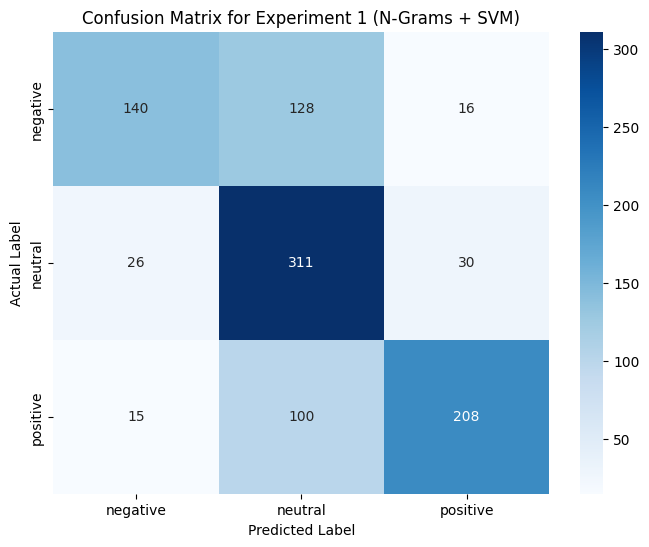

In [321]:
# Visualizing the confusion matrix for Experiment 1
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_svm_ngrams, annot=True, fmt='d', cmap='Blues',
                             xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix for Experiment 1 (N-Grams + SVM)")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.show()

The confusion matrix provides a visual summary of the model’s classification performance across the sentiment classes. The observed misclassification patterns are consistent with the earlier evaluation, particularly the difficulty in distinguishing negative sentiments from neutral ones.

# **Experiment 2: Term Frequency-Inverse Document Frequency + Support Vector Machine**

In experiment 2, TF-IDF(Term Frequency-Inverse Document Frequency) is used as the text representation technique for sentiment classification. Unlike N-gram frequency-based representation, TF-IDF assigns weights to words based on their importance, giving higher weight to terms that are frequent in a document but rare across the dataset.

The lemmatized captions are transformed into a TF-IDF feature matrix, which reflects the relative importance of each term. This representation helps reduce the influence of commonly occurring words while emphasizing more informative terms.

The dataset is then split into training and testing sets, and a Support Vector Machine (SVM) classifier is trained on the training data. The model is subsequently evaluated on the testing data to assess whether TF-IDF improves classification performance compared to the N-gram baseline.

In [322]:
# Initialize the Support Vector Classifier with a linear kernel
svm_classifier = SVC(kernel='linear', random_state=42)

# Train the classifier on the training data
svm_classifier.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred_svm_tfidf = svm_classifier.predict(X_test_tfidf)

# Evaluate the classifier
accuracy_svm_tfidf = accuracy_score(y_test, y_pred_svm_tfidf)
f1_svm_tfidf = f1_score(y_test, y_pred_svm_tfidf, average='weighted')
conf_matrix_svm_tfidf = confusion_matrix(y_test, y_pred_svm_tfidf)
class_report_svm_tfidf = classification_report(y_test, y_pred_svm_tfidf)

# Output the results
print("Accuracy Score Testing (TF-IDF + SVM):", accuracy_svm_tfidf)
print("F1 Score Testing (TF-IDF + SVM):", f1_svm_tfidf)
print("\nConfusion Matrix (TF-IDF + SVM):\n", conf_matrix_svm_tfidf)
print("\nClassification Report (TF-IDF + SVM):\n", class_report_svm_tfidf)

Accuracy Score Testing (TF-IDF + SVM): 0.6909650924024641
F1 Score Testing (TF-IDF + SVM): 0.6929349769893398

Confusion Matrix (TF-IDF + SVM):
 [[169 105  10]
 [ 49 288  30]
 [ 13  94 216]]

Classification Report (TF-IDF + SVM):
               precision    recall  f1-score   support

           0       0.73      0.60      0.66       284
           1       0.59      0.78      0.67       367
           2       0.84      0.67      0.75       323

    accuracy                           0.69       974
   macro avg       0.72      0.68      0.69       974
weighted avg       0.72      0.69      0.69       974



Experiment 2 (TF-IDF + SVM) achieved an overall accuracy of approximately 69.1%, showing a slight improvement over the N-gram baseline model.

From the classification report, the positive class (label 2) achieved the highest F1-score (0.75), indicating strong and balanced performance. The neutral class (label 1) also performed well with an F1-score of 0.67, supported by relatively high recall.

Compared to Experiment 1, the negative class (label 0) shows an improvement in recall (0.60 vs 0.49), suggesting that TF-IDF helps the model better identify negative sentiments.

Overall, the model achieves a weighted F1-score of approximately 0.69, indicating improved performance compared to the baseline. This suggests that TF-IDF provides a more effective feature representation by emphasizing informative words and reducing the influence of common terms.

**Visualize the Performance of Experiment 2**

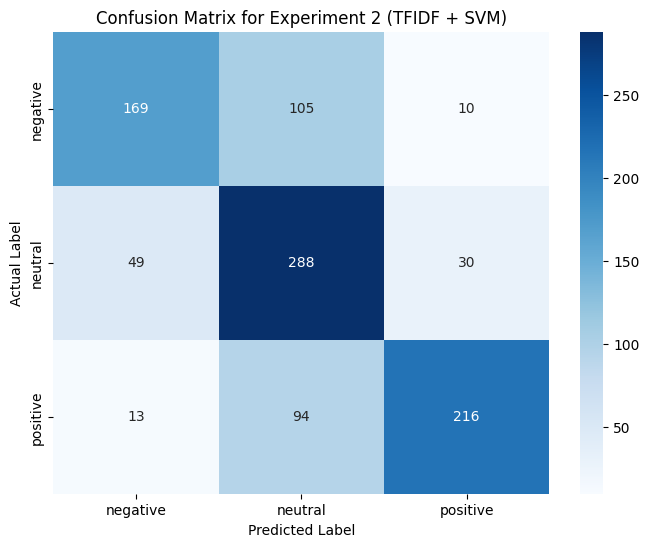

In [323]:
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(conf_matrix_svm_tfidf, annot=True, fmt='d', cmap='Blues',
                      xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for Experiment 2 (TFIDF + SVM)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


The confusion matrix provides a visual summary of the TF-IDF + SVM model’s classification performance. The distribution of predictions is consistent with the earlier evaluation results, showing improved detection of negative sentiments compared to the baseline, while maintaining strong performance on the positive and neutral classes.

# **Experiment 3: Term Frequency-Inverse Document Frequency + Random Forest**

In this experiment 3, TF-IDF vectorization is used together with a Random Forest classifier to perform sentiment classification. While the previous experiments utilized Support Vector Machine (SVM), this experiment explores whether a different machine learning model can improve performance.

Random Forest is an ensemble learning method that builds multiple decision trees and combines their predictions, allowing it to capture more complex patterns in the data. By using the same TF-IDF feature representation, this experiment isolates the impact of the classifier on performance.

The dataset is then split into training and testing sets, and the Random Forest model is trained and evaluated to compare its effectiveness against the SVM-based approaches

In [324]:
# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the classifier on the training data
rf_classifier.fit(X_train_tfidf, y_train)

# Predict on the test set
y_pred_rf_tfidf = rf_classifier.predict(X_test_tfidf)

# Evaluate the classifier
accuracy_rf_tfidf = accuracy_score(y_test, y_pred_rf_tfidf)
f1_rf_tfidf = f1_score(y_test, y_pred_rf_tfidf, average='weighted')
class_report_rf_tfidf = classification_report(y_test, y_pred_rf_tfidf)
conf_matrix_rf_tfidf = confusion_matrix(y_test, y_pred_rf_tfidf)

# Output the results
print("Accuracy Score Testing (TF-IDF + RF):", accuracy_rf_tfidf)
print("F1 Score Testing (TF-IDF + RF):", f1_rf_tfidf)
print("\nConfusion Matrix (TF-IDF + RF):\n", conf_matrix_rf_tfidf)
print("\nClassification Report (TF-IDF + RF):\n", class_report_rf_tfidf)

Accuracy Score Testing (TF-IDF + RF): 0.704312114989733
F1 Score Testing (TF-IDF + RF): 0.7033871652948251

Confusion Matrix (TF-IDF + RF):
 [[154 117  13]
 [ 29 303  35]
 [ 12  82 229]]

Classification Report (TF-IDF + RF):
               precision    recall  f1-score   support

           0       0.79      0.54      0.64       284
           1       0.60      0.83      0.70       367
           2       0.83      0.71      0.76       323

    accuracy                           0.70       974
   macro avg       0.74      0.69      0.70       974
weighted avg       0.73      0.70      0.70       974



Experiment 3 (TF-IDF + Random Forest) achieved an overall accuracy of approximately 70.4%, showing a slight improvement over the TF-IDF + SVM model.

Based on the classification report, the positive class (label 2) achieved the highest F1-score (0.76), indicating strong and balanced performance. The neutral class (label 1) also performed well with an F1-score of 0.70, supported by high recall.

Compared to Experiment 2, the model shows a slight improvement across most metrics, particularly in overall accuracy and weighted F1-score. However, the negative class (label 0) still has relatively lower recall (0.54), suggesting that identifying negative sentiments remains more challenging.

Overall, the model achieves a weighted F1-score of approximately 0.70, indicating the best performance among all experiments. This suggests that combining TF-IDF with a Random Forest classifier provides a more effective approach for sentiment classification in this dataset.

**Visualize the Performance of Experiment 3**

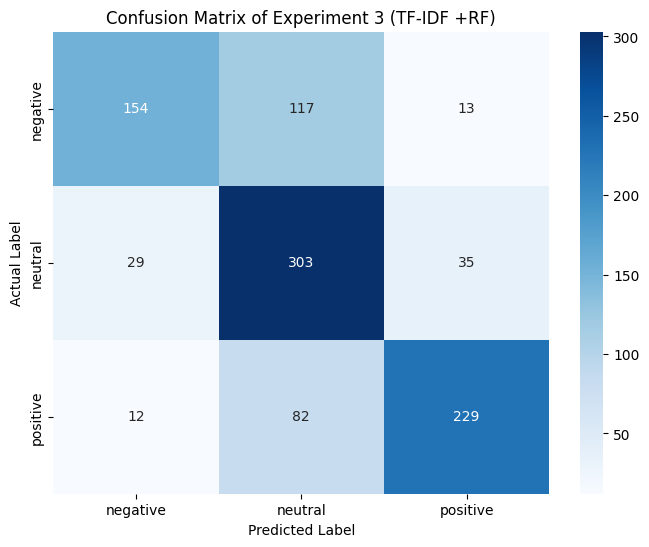

In [325]:
# Visualizing the confusion matrix for TF-IDF + Random Forest
plt.figure(figsize=(8, 6))
heatmap_rf = sns.heatmap(conf_matrix_rf_tfidf, annot=True, fmt='d', cmap='Blues',
                         xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix of Experiment 3 (TF-IDF +RF)')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

Insights:

The confusion matrix shows that the model performs well in identifying positive and neutral sentiments, with a high number of correct predictions along the diagonal. However, negative sentiments are more frequently misclassified as neutral, indicating difficulty in distinguishing between these two classes.

Overall, the model demonstrates solid classification performance, though improvements can still be made in better separating negative and neutral sentiments.

# **Model Performance Comparison Across Experiments**

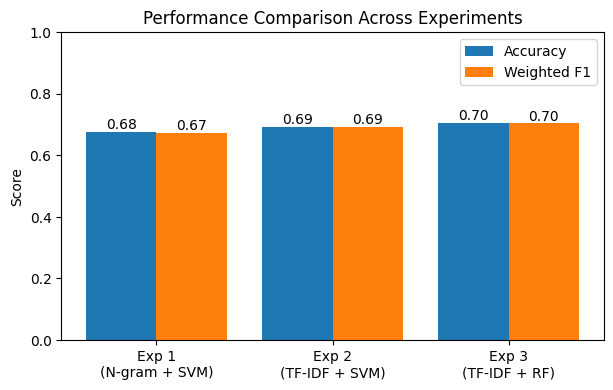

In [329]:
experiments = ['Exp 1\n(N-gram + SVM)', 
               'Exp 2\n(TF-IDF + SVM)', 
               'Exp 3\n(TF-IDF + RF)']

accuracies = [accuracy_svm_ngrams, accuracy_svm_tfidf, accuracy_rf_tfidf]

f1_scores = [f1_svm_ngrams, f1_svm_tfidf, f1_rf_tfidf]

x = range(len(experiments))

plt.figure(figsize=(7, 4))
plt.bar(x, accuracies, width=0.4, label='Accuracy')
plt.bar([i + 0.4 for i in x], f1_scores, width=0.4, label='Weighted F1')

plt.xticks([i + 0.2 for i in x], experiments)
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Performance Comparison Across Experiments')
plt.legend()

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center')

for i, v in enumerate(f1_scores):
    plt.text(i + 0.4, v + 0.01, f'{v:.2f}', ha='center')

plt.show()

The comparison chart illustrates the performance of all three experiments in terms of accuracy and weighted F1-score.

It can be observed that Experiment 3 (TF-IDF + Random Forest) achieves the highest performance across both metrics, followed by Experiment 2 (TF-IDF + SVM), while Experiment 1 (N-gram + SVM) shows the lowest performance.

This indicates that TF-IDF provides a more effective text representation than N-grams, and that Random Forest further improves performance compared to SVM. Overall, the combination of TF-IDF and Random Forest yields the best results for sentiment classification in this study.

## **Conclusion**

This study explored different text representation techniques and machine learning models for sentiment classification. The results show that TF-IDF consistently outperforms N-gram representations, while Random Forest achieves the best overall performance among the tested models. Despite strong performance, challenges remain in accurately classifying negative sentiments. Future work may explore deep learning models or more advanced embeddings to further improve performance.